In [1]:
# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Lectura csv final
df_final = pd.read_csv('files/hr_final.csv', index_col = 0)
df_final.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,41,True,Travel Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993.0,19479,8,True,11,3,1,0,8,0,1,6,4,0,5
2,49,False,Travel Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130.0,24907,1,False,23,4,4,1,10,3,3,10,7,1,7
4,37,True,Travel Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090.0,2396,6,True,15,3,2,0,7,3,3,0,0,0,0
5,33,False,Travel Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909.0,23159,1,True,11,3,3,0,8,3,3,8,7,3,0
7,27,False,Travel Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468.0,16632,9,False,12,3,4,1,6,3,3,2,2,2,2


### Recuperamos la división de variables utilizada en el 02_Analisis

In [3]:
variables_categoricas = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',  'MaritalStatus', 'OverTime']

In [4]:
variables_encuesta = ['EnvironmentSatisfaction', 'JobInvolvement','JobSatisfaction','RelationshipSatisfaction','WorkLifeBalance']

In [5]:
variables_salario = ['DailyRate','HourlyRate', 'MonthlyRate','MonthlyIncome','PercentSalaryHike']
variables_tiempo = [ 'TotalWorkingYears','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']
variables_numericas1 = ['DistanceFromHome','JobLevel','PerformanceRating','StockOptionLevel','TrainingTimesLastYear']
variables_numericas2= ['Age', 'Education','NumCompaniesWorked']

In [6]:
# Conversión de Attrition en numérica para los gráficos
df_final['AttritionNum'] = df_final['Attrition'].astype(int)

### Correlación de attrition (abandono de la empresa) con las variables categóricas

In [7]:
# Función para dibujar gráficos de barras agrupando por abandono de empresa 
def crear_graficos_barras(df, variables):
    
    for col in variables:

        # Barplot (tasa de attrition por categoría)
        plt.figure(figsize=(8, 5))
        tasa = df.groupby(col)['AttritionNum'].mean().sort_values(ascending=False)
        sns.barplot(x=tasa.index, y=tasa.values, palette='mako')
        plt.title(f'Tasa de Abandono por {col}')
        plt.ylabel('Proporción que se va')
        plt.xlabel(col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

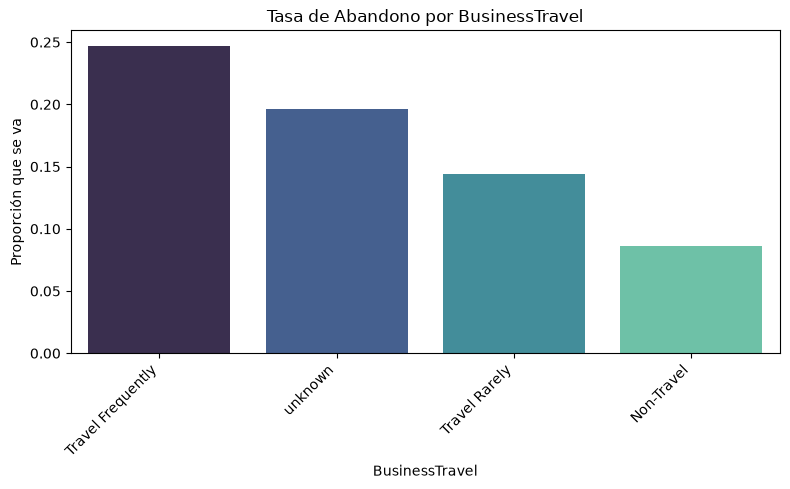

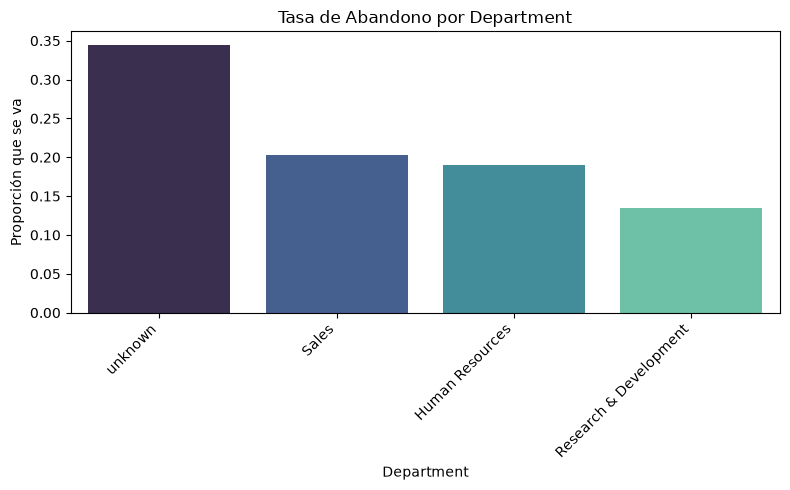

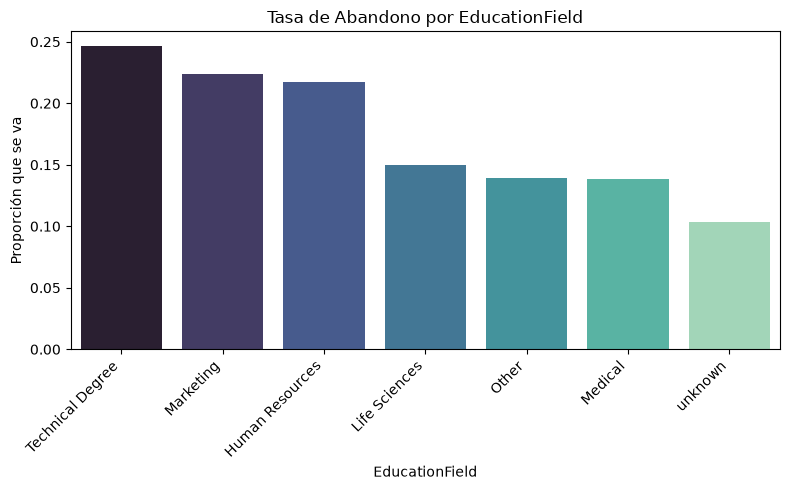

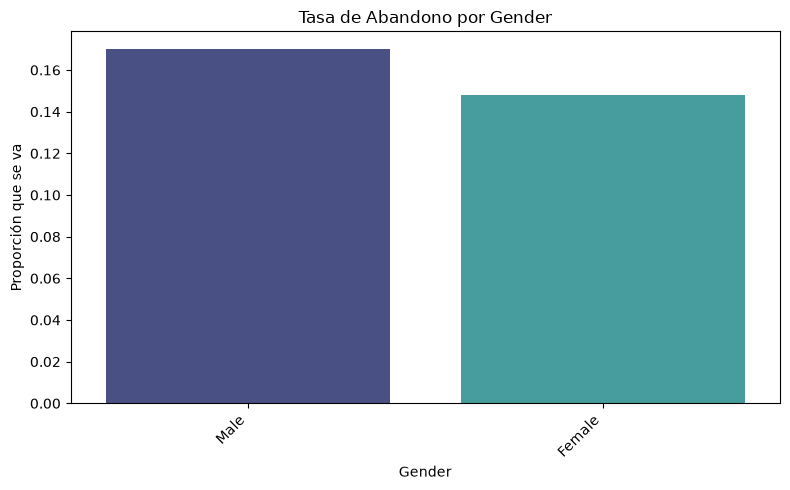

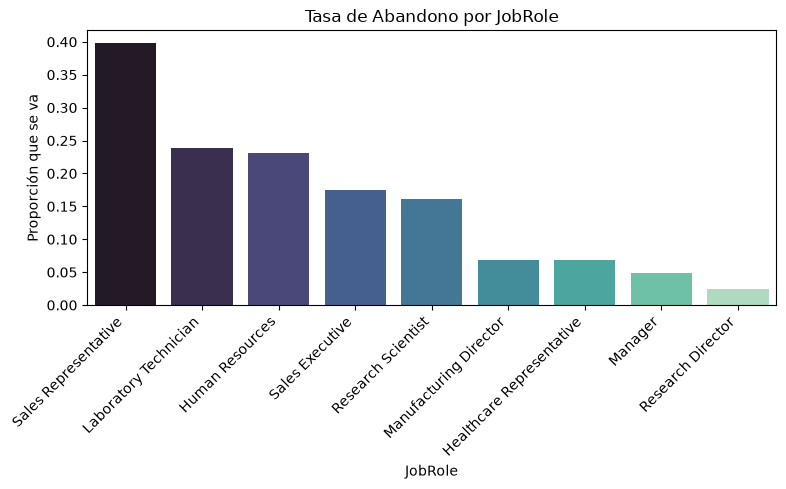

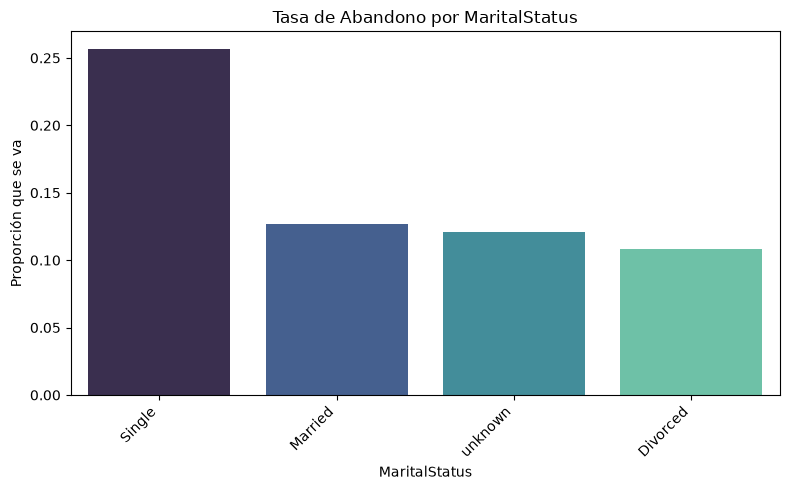

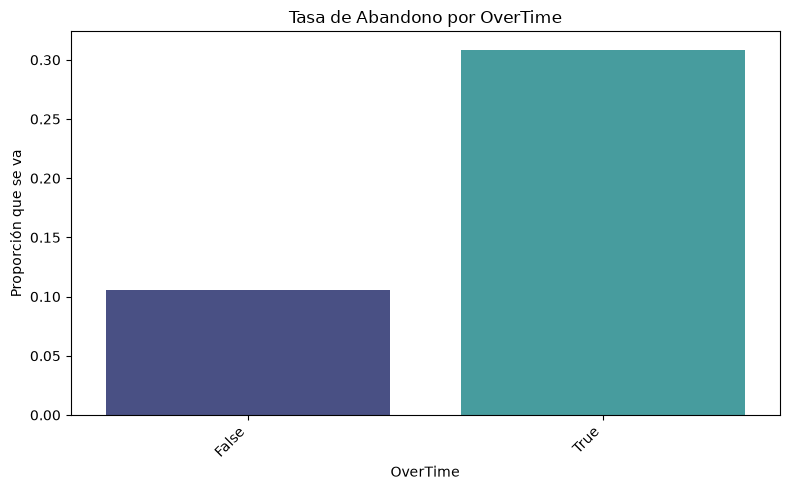

In [8]:
# Ejecución de la función para variables categóricas
crear_graficos_barras(df_final, variables_categoricas)

### Correlación de attrition con las variables encuesta

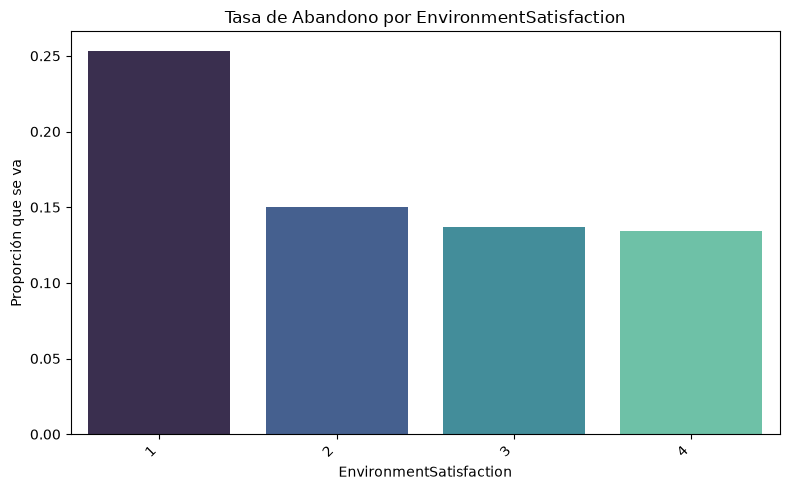

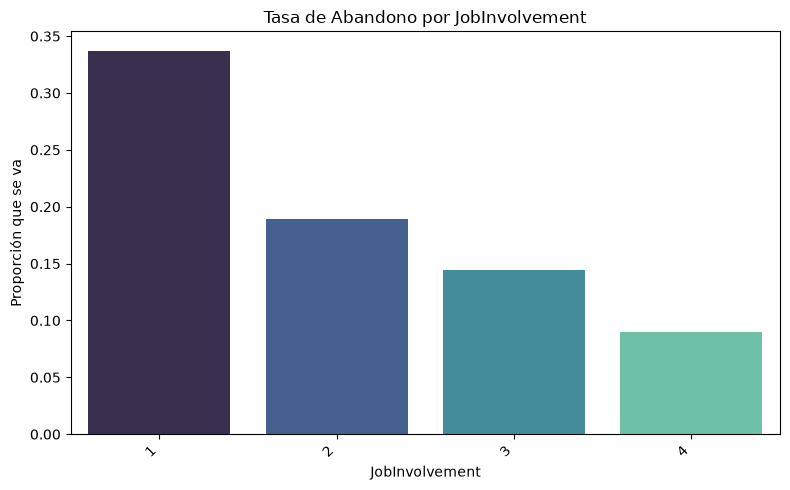

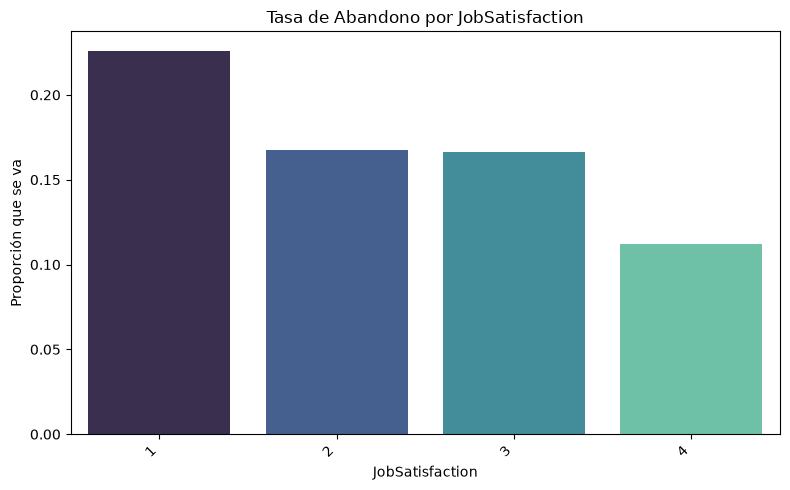

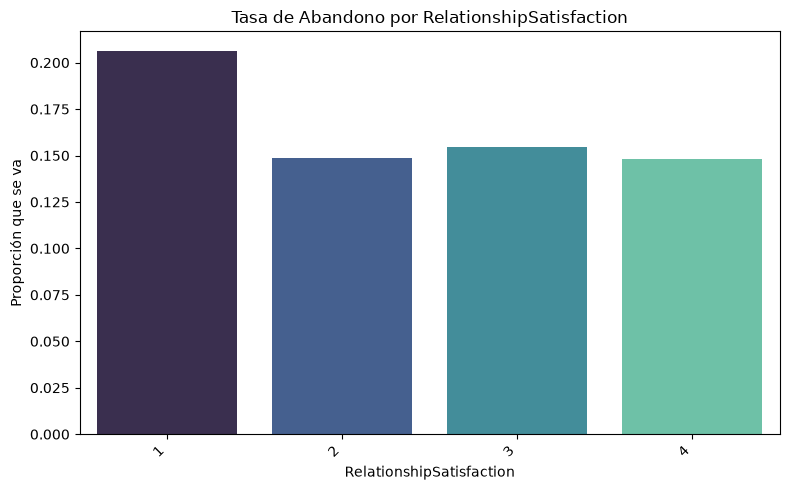

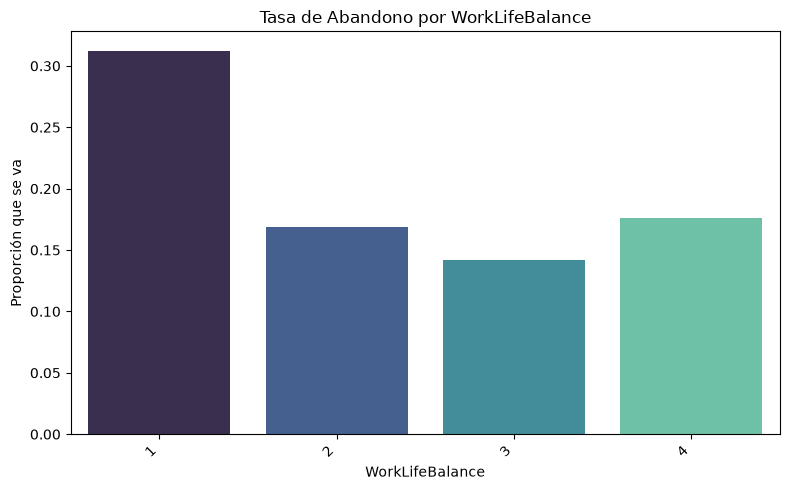

In [9]:
# Ejecución de la función para variables encuestas
crear_graficos_barras(df_final, variables_encuesta)

### Matriz de correlación entre variables numéricas

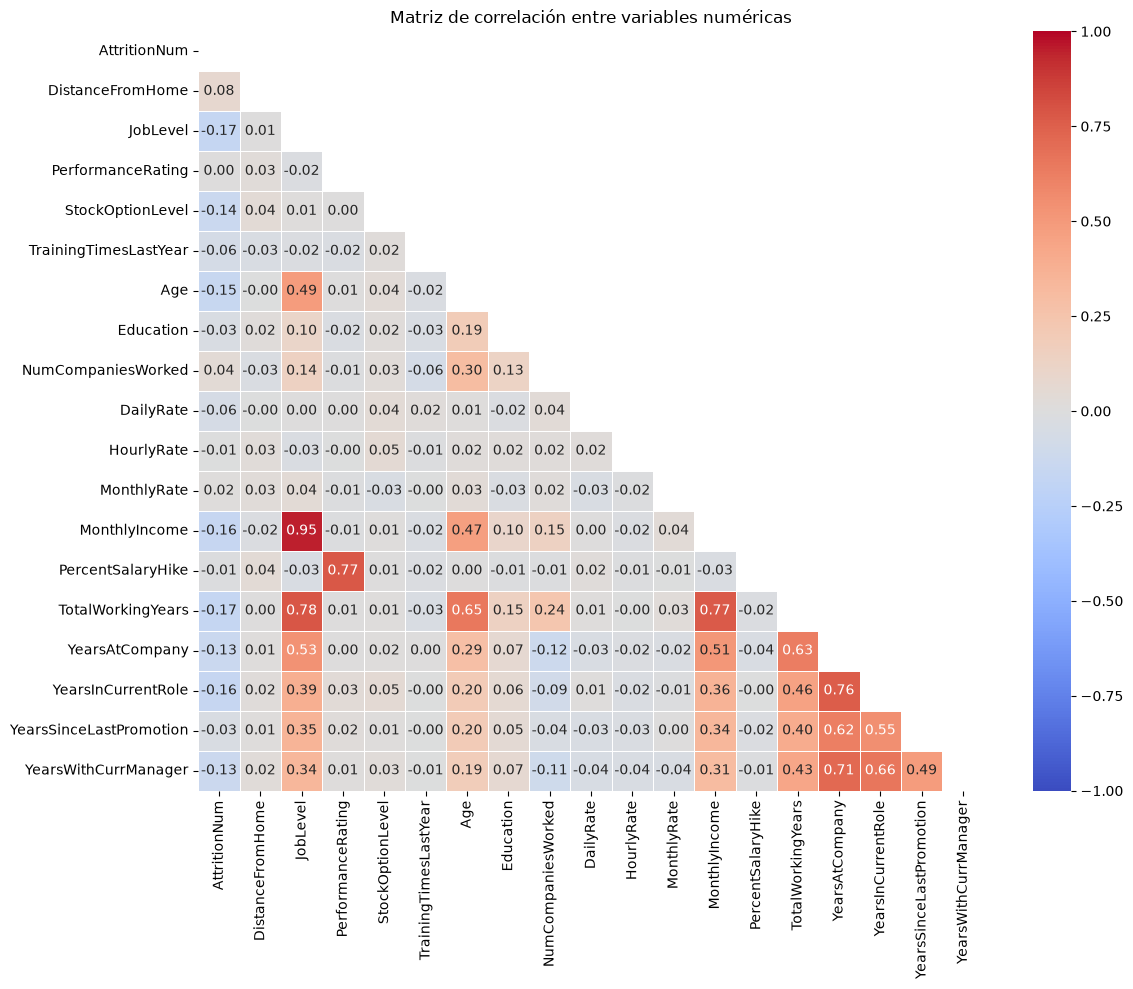

In [10]:
# Creación del mapa de correlación entre variables numericas y abandono
cols_heatmap = ['AttritionNum'] + list(dict.fromkeys(variables_numericas1 + variables_numericas2 + variables_salario + variables_tiempo)) 
correlacion_matrix = df_final[cols_heatmap].corr()

# Aplicación de máscara para evitar duplicidad en la matriz
masc = np.triu(np.ones_like(correlacion_matrix, dtype=bool)) 
plt.figure(figsize=(12, 10))
sns.heatmap(correlacion_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, mask=masc, vmin=-1, vmax=1)
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

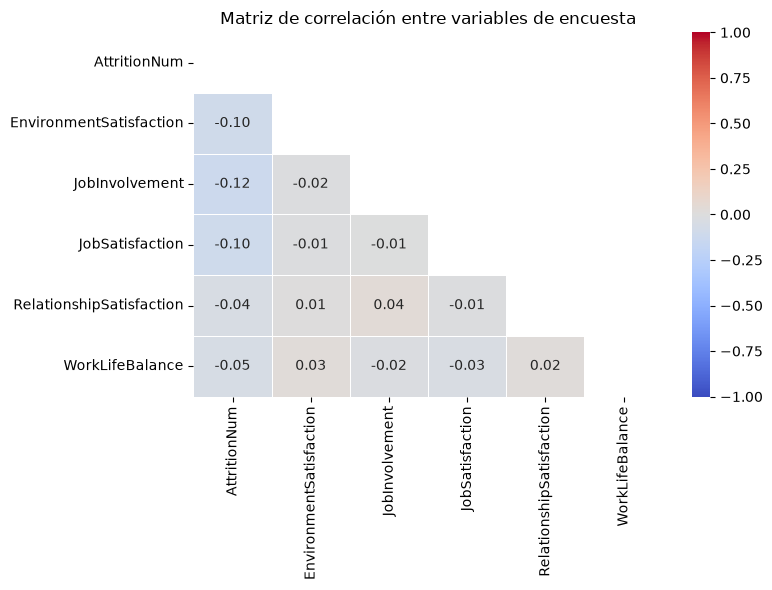

In [11]:
# Creación del mapa de correlación entre variables de encuenta y abandono
cols_heatmap2 = ['AttritionNum'] + variables_encuesta

# Se usa el metodo de 'spearman' porque mide relaciones monótonas
correlacion_matrix2 = df_final[cols_heatmap2].corr(method='spearman')

# Aplicación de máscara para evitar duplicidad en la matriz
masc2 = np.triu(np.ones_like(correlacion_matrix2, dtype=bool)) 
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion_matrix2, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, mask=masc2, vmin=-1, vmax=1)
plt.title('Matriz de correlación entre variables de encuesta')
plt.tight_layout()
plt.show()

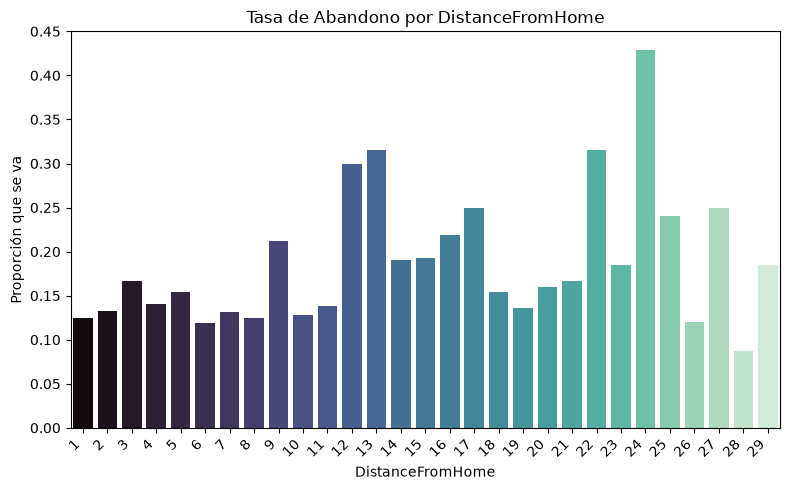

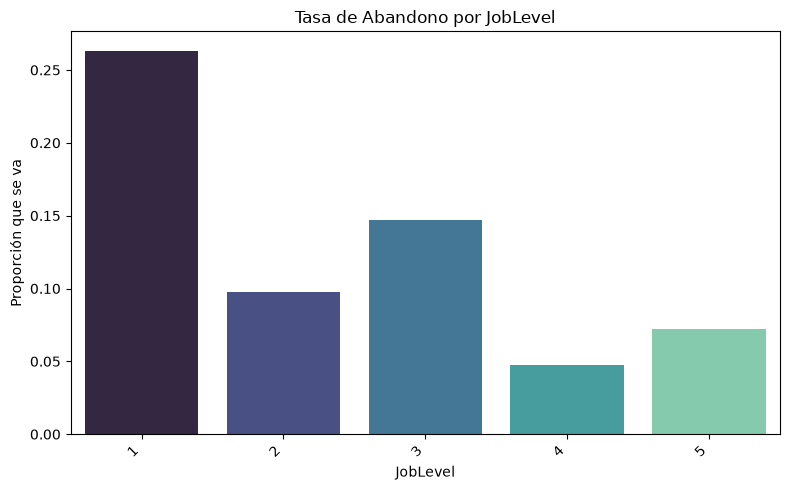

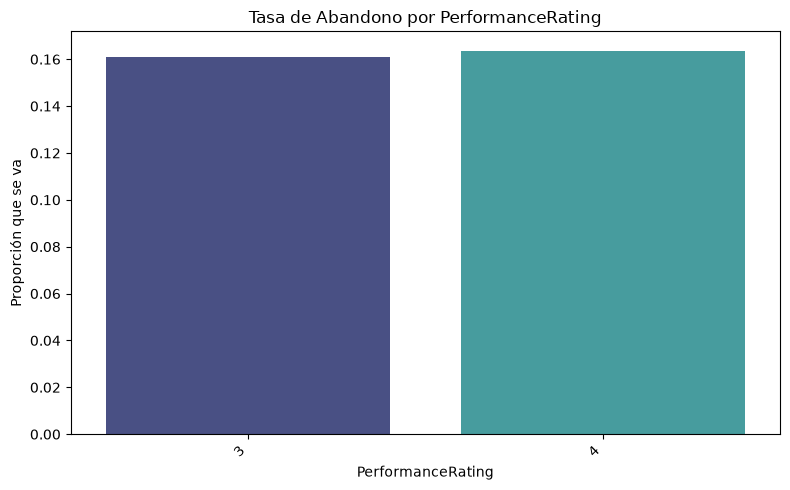

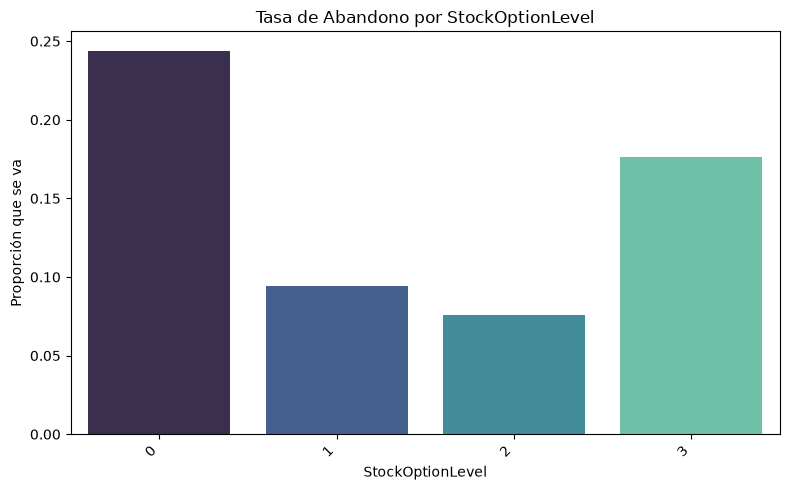

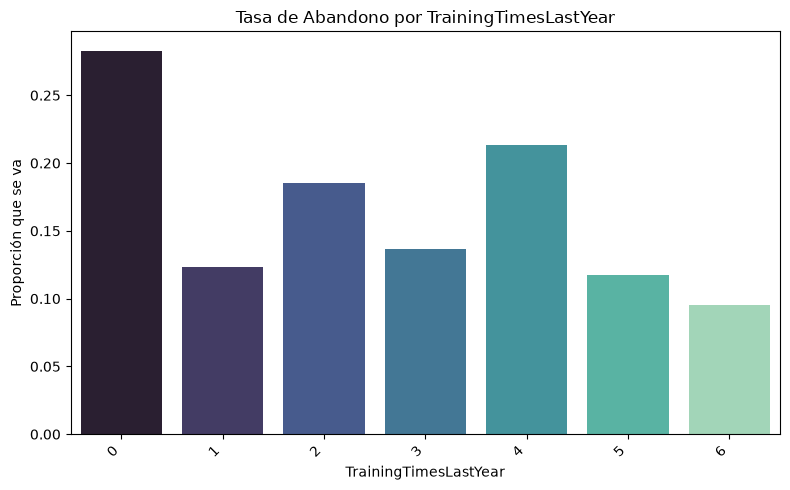

In [12]:
# Ejecución de la función para variables numéricas 1
crear_graficos_barras(df_final, variables_numericas1)

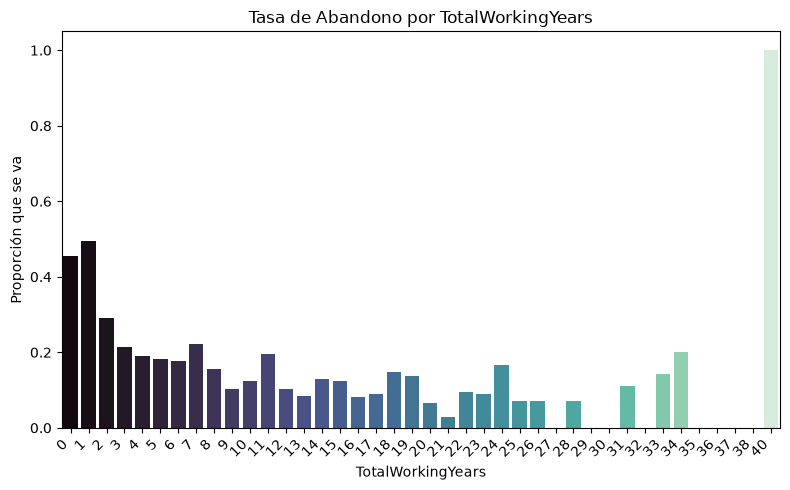

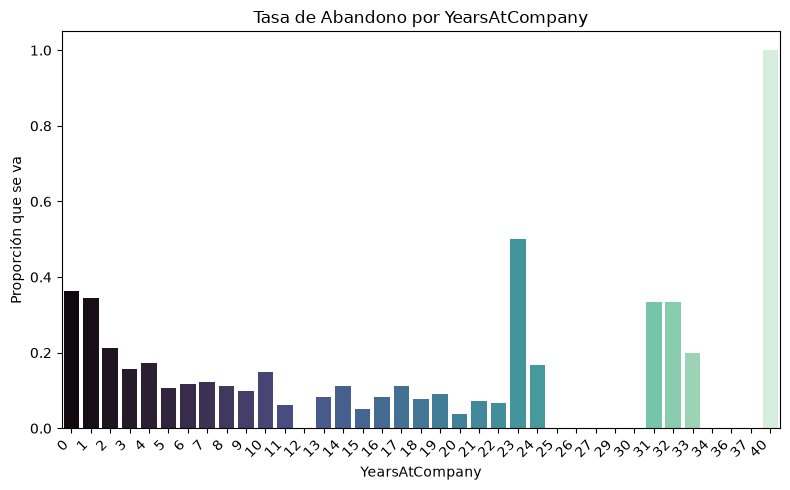

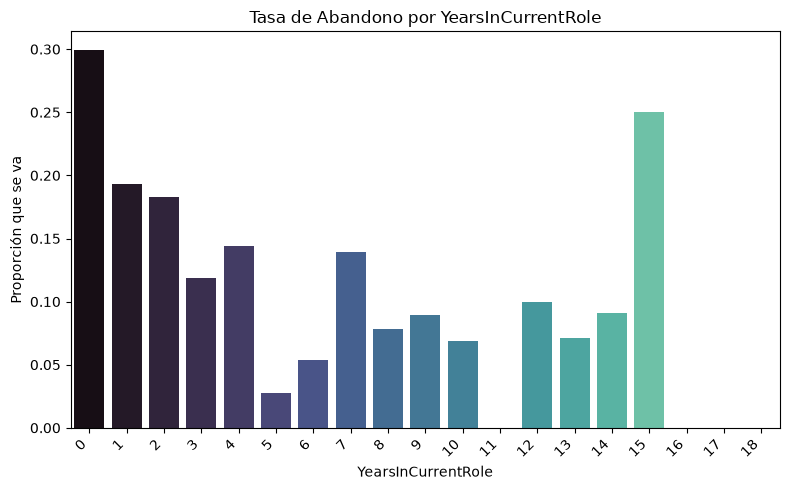

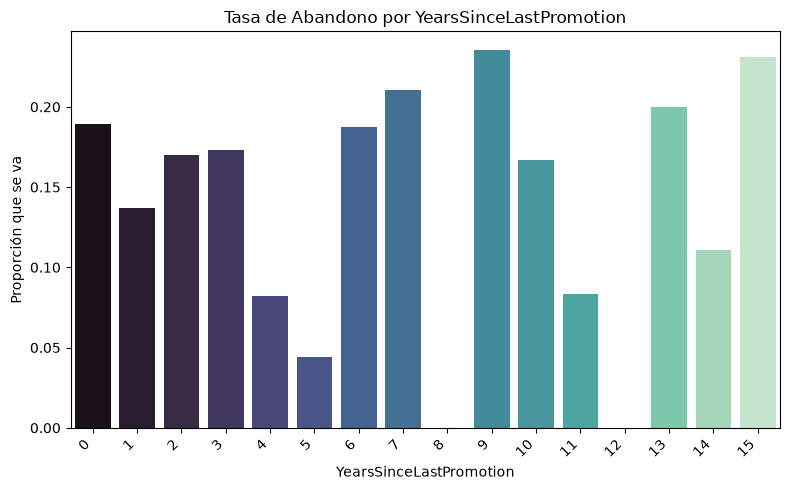

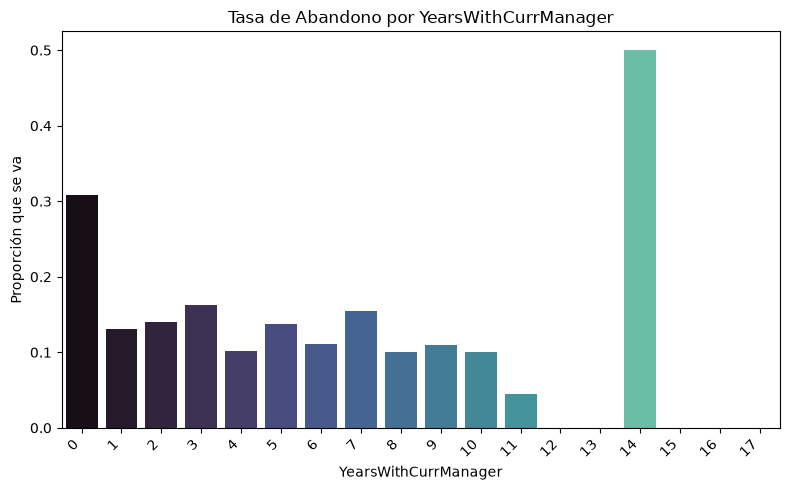

In [13]:
# Ejecución de la función para variables tiempo
crear_graficos_barras(df_final, variables_tiempo)

In [14]:
#Para comprobar si el alto porcentaje de los que llevan más años trabajando en la compañía y en total y se va es debido a la jubilación


# Personas que llevan más de 35 años en la compañía
mas_35_compania = df_final[df_final["YearsAtCompany"] > 35]

mas_35_compania[["Age", "YearsAtCompany", "TotalWorkingYears", "AttritionNum"]]

,Age,YearsAtCompany,TotalWorkingYears,AttritionNum
EmployeeNumber,,,,
131,58,37,38,0
165,58,40,40,1
374,55,36,37,0
1578,55,36,36,0


In [15]:
# Personas que llevan más de 35 años trabajando en total
mas_35_total = df_final[df_final["TotalWorkingYears"] > 35]

mas_35_total[["Age", "YearsAtCompany", "TotalWorkingYears", "AttritionNum"]]

,Age,YearsAtCompany,TotalWorkingYears,AttritionNum
EmployeeNumber,,,,
112,56,6,37,0
131,58,37,38,0
165,58,40,40,1
254,55,24,36,0
374,55,36,37,0
532,56,7,36,0
597,55,10,37,0
825,58,31,40,1
1250,54,10,36,0


Desconocemos la edad de jubilación del país al que pertenece la empresa. Pero tras ver los gráficos correspondientes a `TotalWorkingYears` y `YearsAtCompany`, se podía pensar que el pico de salidas de aquellos que más años llevan trabajando y que más años llevan en la compañía se debe a la jubilación. 

Tras analizar los resultados de la tabla, el pico en el gráfico se debe a que las dos personas de 58 años de edad, que tras haber trabajado 40 años (una de ellas ha hecho toda su vida laboral en la compañía) se han marchado (es decir, el 100% de los que han trabajado 40 años). Lo mismo ocurre con `YearsAtCompany`, la única persona que lleva 40 años en la empresa se ha ido, por tanto corresponde al 100%.

* CONCLUSIÓN: No se puede afirmar con rotundidad que se debe a la jubilación ya que desconocemos la edad reglamentaria de retiro en el país en el que opera la empresa, pero apunta a que esas dos personas se han jubilado o prejubilado tras 40 años trabajados, por lo que su caso no sería reseñable para este estudio. 

### Agrupación en rangos salariales para el estudio de MonthlyIncome

In [16]:
# Análisis MonthlyIncome
print (f'Mínimo: {df_final["MonthlyIncome"].min()}')
print (f'Máximo: {df_final["MonthlyIncome"].max()}')

Mínimo: 1009.0
Máximo: 19999.0


In [17]:
# División en 8 intervalos del mismo tamaño
df_final["RangoSalarial"] = pd.cut(
    df_final["MonthlyIncome"],
    bins=8)

In [18]:
# Visualización de los intervalos
df_final["RangoSalarial"].value_counts().sort_index()

RangoSalarial
(990.01, 3382.75]      444
(3382.75, 5756.5]      448
(5756.5, 8130.25]      207
(8130.25, 10504.0]     125
(10504.0, 12877.75]     60
(12877.75, 15251.5]     55
(15251.5, 17625.25]     54
(17625.25, 19999.0]     77
Name: count, dtype: int64

In [19]:
# Se calcula el porcentaje de empleados que se han quedado en la empresa por rango salarial
retencion_salario = df_final.groupby("RangoSalarial")["Attrition"].apply(lambda x: 1 - x.mean()) * 100

retencion_salario = retencion_salario.round(2)
retencion_salario.sort_index()

RangoSalarial
(990.01, 3382.75]       73.20
(3382.75, 5756.5]       87.28
(5756.5, 8130.25]       88.89
(8130.25, 10504.0]      81.60
(10504.0, 12877.75]     91.67
(12877.75, 15251.5]     90.91
(15251.5, 17625.25]    100.00
(17625.25, 19999.0]     93.51
Name: Attrition, dtype: float64

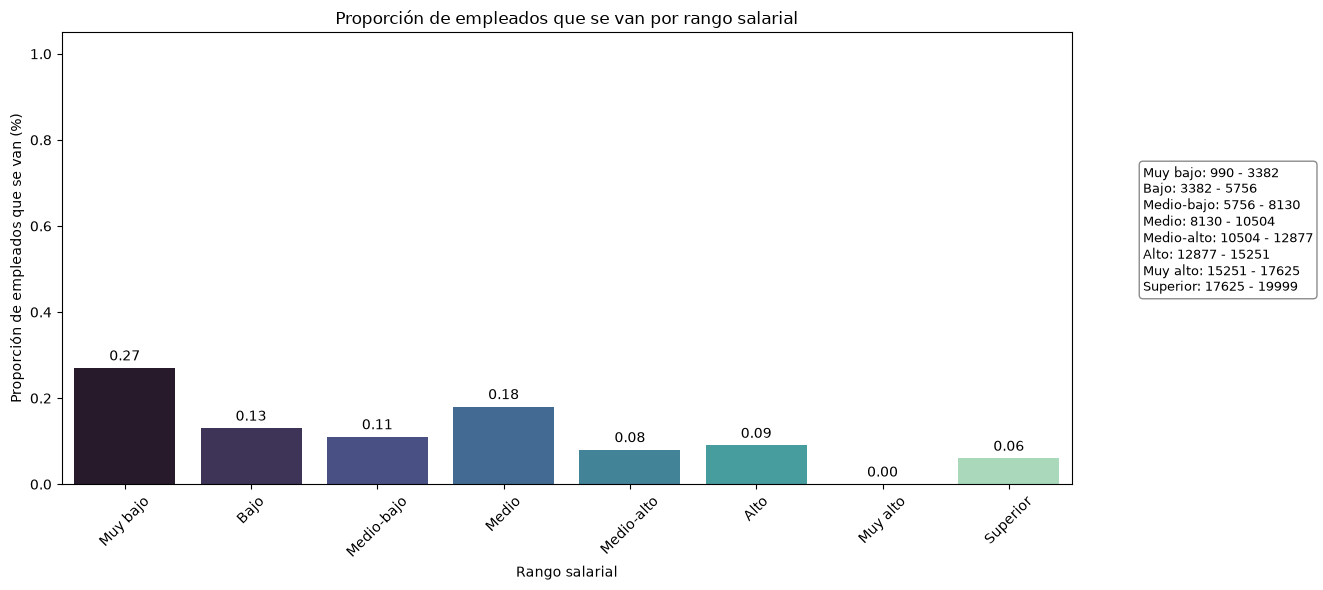

In [20]:
# Etiquetas para los intervalos
labels_salario = [
    "Muy bajo",
    "Bajo",
    "Medio-bajo",
    "Medio",
    "Medio-alto",
    "Alto",
    "Muy alto",
    "Superior"
]
# Se crea la columna de rango salarial
df_final["RangoSalarial"] = pd.cut(
    df_final["MonthlyIncome"],
    bins=8,
    labels=labels_salario
)

proporcion_salida_salario = (
    df_final
    .groupby("RangoSalarial", observed=True)["AttritionNum"]
    .mean()
    .round(2)
)

intervalos_salario = pd.cut(
    df_final["MonthlyIncome"],
    bins=8
).cat.categories

# Gráfico
texto_leyenda = "\n".join(
    [
        f"{categoria}: {int(intervalo.left)} - {int(intervalo.right)}"
        for categoria, intervalo in zip(labels_salario, intervalos_salario)
    ]
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    x=proporcion_salida_salario.index,
    y=proporcion_salida_salario.values,
    order=labels_salario,
    palette='mako'
)

plt.title("Proporción de empleados que se van por rango salarial")
plt.xlabel("Rango salarial")
plt.ylabel("Proporción de empleados que se van (%)")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)

for i, valor in enumerate(proporcion_salida_salario.values):
    ax.text(
        i,
        valor + 0.01,
        f"{valor:.2f}",
        ha="center",
        va="bottom"
    )

plt.gcf().text(
    0.82,
    0.5,
    texto_leyenda,
    fontsize=9,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

In [ ]:
# Etiqueta más legible
df_final["Attrition_label"] = df_final["Attrition"].map({
    True: "Se marcha",
    False: "Se queda"
})

colores_mako = sns.color_palette("mako", 2)

# Función para comparar los que se van y los que se quedan con diferentes variables
def grafico_barras_attrition(variable, bins=None, orden=None):
    data = df_final.copy()

    if bins:
        data[variable + "_grupo"] = pd.cut(data[variable], bins=bins)
        variable_plot = variable + "_grupo"
    else:
        variable_plot = variable

    tabla = pd.crosstab(
        data[variable_plot],
        data["Attrition_label"],
        normalize="index"
    ) * 100

    if orden:
        tabla = tabla.reindex(orden)

    ax = tabla.plot(
        kind="bar",
        figsize=(10, 5),
        color=colores_mako,
        width=0.8
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            fontsize=9,
            padding=3
        )
    plt.title(f"Distribución de {variable} según Attrition")
    plt.xlabel(variable)
    plt.ylabel("% dentro de cada grupo Attrition")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Attrition")
    plt.tight_layout()
    plt.show()


    #En este caso usamos normalize="index" para calcular el porcentaje de empleados 
    # que se marchan o se quedan dentro de cada categoría o intervalo de la variable analizada. 
    # Es decir, responde a la pregunta: de todos los empleados que tienen este valor concreto 
    # en la variable, ¿qué porcentaje se marcha y qué porcentaje permanece?

## Comparaciones entre los que se marchan y los que se quedan

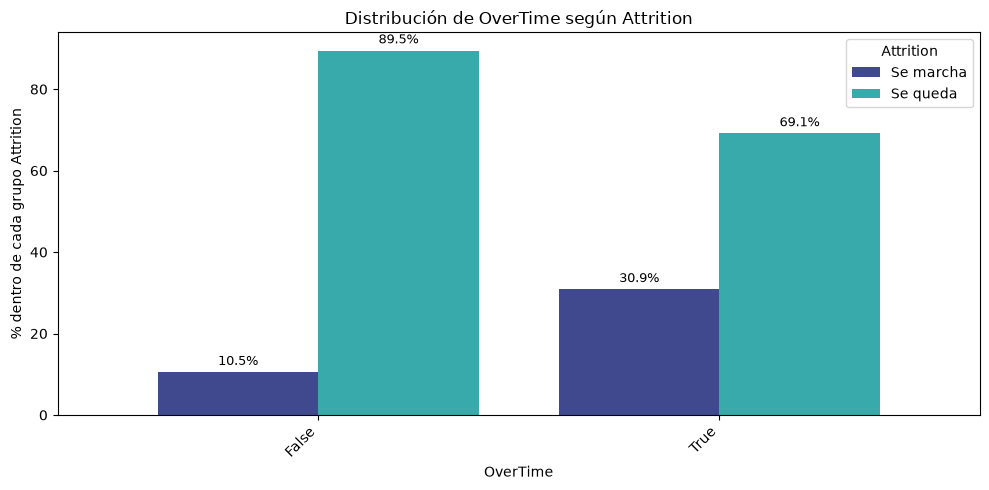

In [53]:
grafico_barras_attrition('OverTime', bins=None, orden=None)

En este gráfico, podemos observar que de los que no hacen horas extra, se marchan el 10.5% frente al 89,5% que se queda. Mientras, entre los que hacen horas extra, se va el 30,9%, frente al 69,1% que se queda.

Por tanto, se puede deducir que las horas extra pueden ser un factor que influya en la decisión de marcharse, pero no el único, ya que hay casi un 70% de empleados que, pese a hacer horas extra, se quedan.

In [74]:
#Análisis para ver si los que se van por horas extra puntúan mal el equilibrio vida-trabajo

# Filtramos empleados que hacen horas extra y se marchan
overtime_se_marcha = df_final[
    (df_final["OverTime"] == True) &
    (df_final["Attrition"] == True)
]

# Distribución de WorkLifeBalance dentro de ese grupo
distribucion_wlb_overtime_attrition = (
    overtime_se_marcha["WorkLifeBalance"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

distribucion_wlb_overtime_attrition

WorkLifeBalance
1     8.0
2    25.6
3    56.8
4     9.6
Name: proportion, dtype: float64

In [ ]:
#Dentro de quienes hacen horas extra, ¿los que se marchan tienen peor WorkLifeBalance que los que se quedan?

comparacion_overtime_wlb = df_final[df_final["OverTime"] == True].groupby("Attrition_label")["WorkLifeBalance"].apply(
    lambda x: (x.isin([1, 2]).mean() * 100)
).reset_index(name="% WorkLifeBalance bajo")

comparacion_overtime_wlb

,Attrition_label,% WorkLifeBalance bajo
0,Se marcha,33.600000
1,Se queda,29.285714


Las horas extra parecen estar asociadas a mayor rotación, pero no necesariamente porque quienes las realizan valoren mucho peor su equilibrio vida-trabajo. La diferencia en WorkLifeBalance bajo entre quienes se marchan y quienes se quedan es limitada.

In [79]:
# Análisis para ver si quienes hacen horas extra y se marchan
# pertenecen a puestos de nivel más bajo o más alto

comparacion_overtime_level = (
    df_final[df_final["OverTime"] == True]
    .groupby("Attrition_label")["JobLevel"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("porcentaje")
    .reset_index()
)

comparacion_overtime_level.round(2)

,Attrition_label,JobLevel,porcentaje
0,Se marcha,1,64.80
1,Se marcha,2,20.00
2,Se marcha,3,10.40
3,Se marcha,5,2.40
4,Se marcha,4,2.40
5,Se queda,2,42.50
6,Se queda,1,24.64
7,Se queda,3,16.79
8,Se queda,4,10.71
9,Se queda,5,5.36


In [80]:
#Qué nivel hace más horas extra

tabla_overtime_level = pd.crosstab(
    df_final["JobLevel"],
    df_final["OverTime"],
    normalize="index"
) * 100

tabla_overtime_level.round(1)

OverTime,False,True
JobLevel,,
1,72.4,27.6
2,73.0,27.0
3,72.5,27.5
4,68.9,31.1
5,73.9,26.1


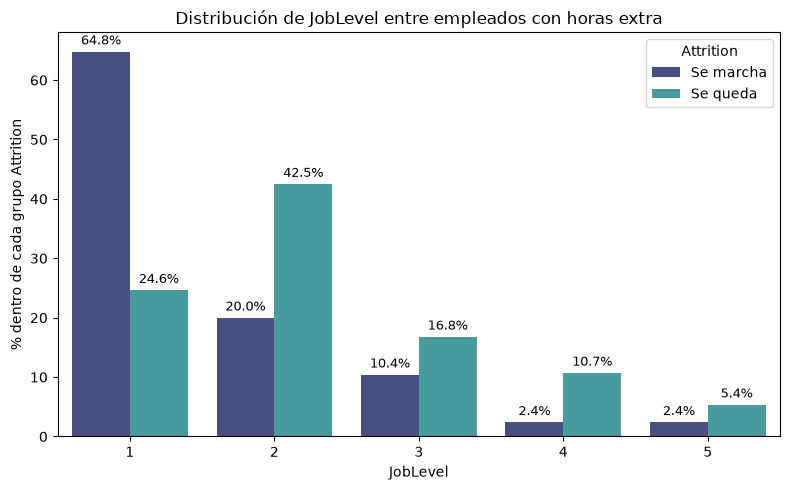

In [78]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparacion_overtime_level,
    x="JobLevel",
    y="porcentaje",
    hue="Attrition_label",
    palette=colores_mako
)

plt.title("Distribución de JobLevel entre empleados con horas extra")
plt.xlabel("JobLevel")
plt.ylabel("% dentro de cada grupo Attrition")
plt.legend(title="Attrition")

for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.1f%%", fontsize=9, padding=3)

plt.tight_layout()
plt.show()

Las horas extra no se concentran claramente en los niveles más bajos, ya que todos los JobLevel presentan porcentajes similares de empleados con `OverTime`=True. No obstante, cuando se combinan horas extra y bajo nivel profesional, la rotación aumenta de forma más notable.

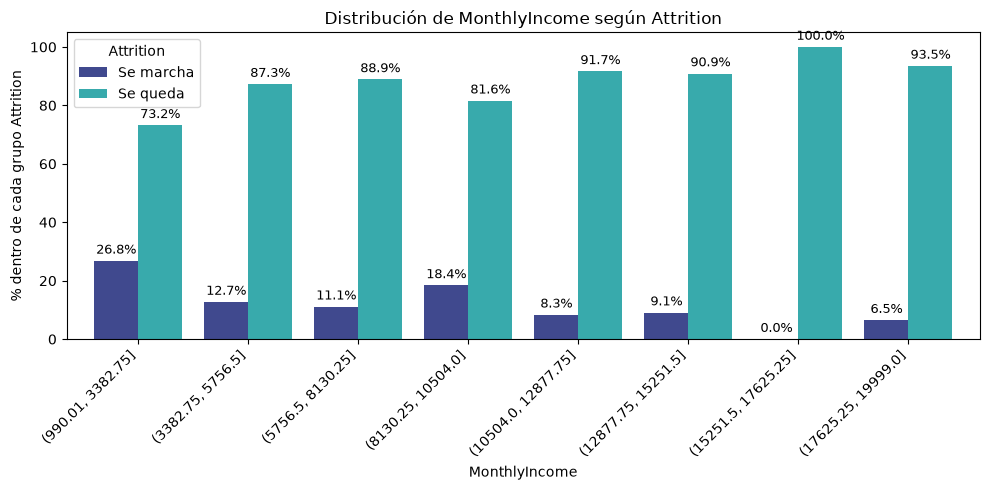

In [54]:
grafico_barras_attrition('MonthlyIncome', bins=8, orden=None)

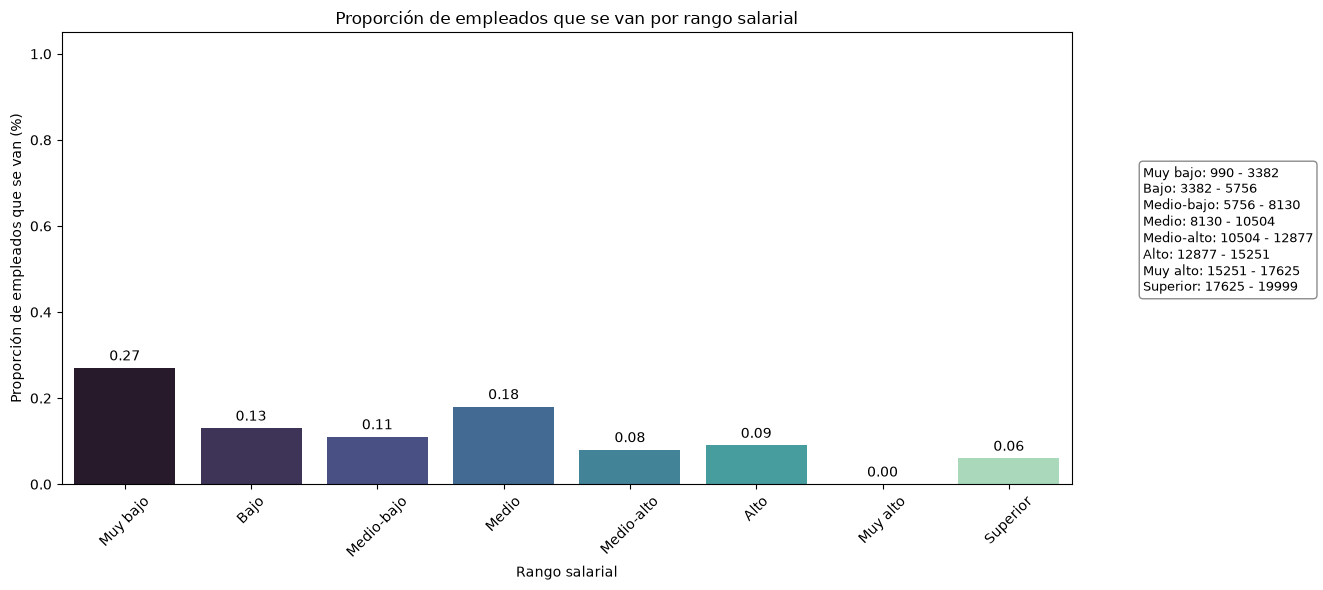

De acuerdo con el gráfico anteriormente hecho (recuperado para este análisis) sobre la proporción de empleados que se van por rango salarial, podemos confirmar que, efectivamente, el porcentaje de trabajadores que se marchan es mayor entre quienes los salarios más bajos. Salvando la excepción de los que tienen un salario medio (de 8130 a 10504), entre quienes también es mayor el porcentaje de los que se van en relación con el resto de grupos salariales, en el resto de intervalos el porcentaje de rotación se mantiene más o menos similar.

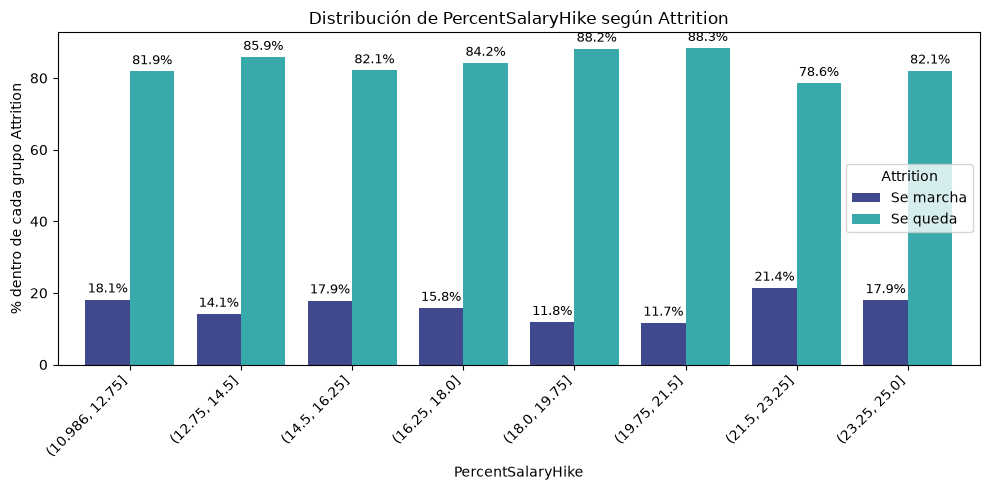

In [68]:
grafico_barras_attrition('PercentSalaryHike', bins=8, orden=None)

El porcentaje de incremento salarial no muestra una relación clara con la rotación. Aunque existen diferencias entre intervalos, no se observa una tendencia progresiva que indique que menores subidas salariales estén asociadas sistemáticamente a una mayor salida de empleados. De hecho, algunos tramos con incrementos más altos también presentan porcentajes de rotación elevados. Por tanto, `PercentSalaryHike` no parece actuar como una variable especialmente determinante por sí sola.

Para interpretar correctamente los tramos extremos, convendría revisar cuántos empleados hay en cada intervalo, ya que algunos porcentajes pueden estar condicionados por grupos pequeños.

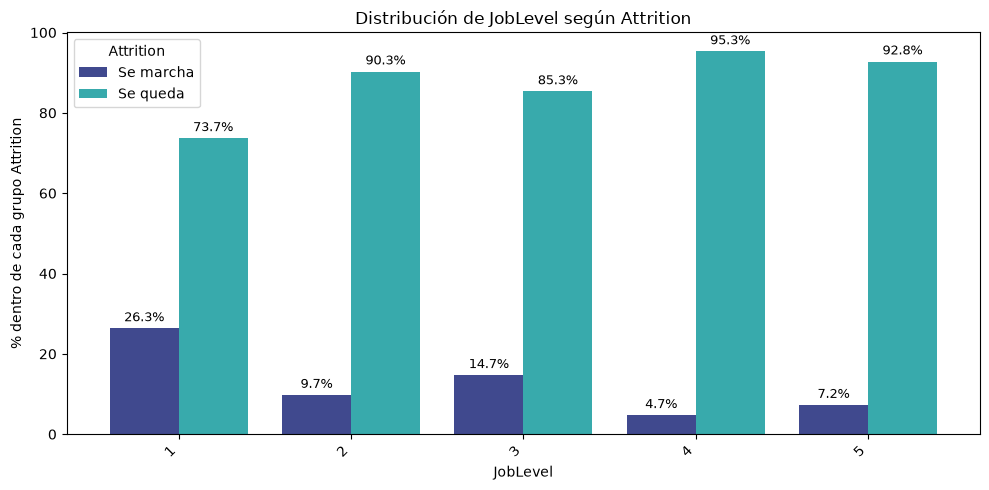

In [55]:
grafico_barras_attrition('JobLevel', bins=0, orden=None)

Teniendo en cuenta que `MonthlyIncome` y `JobLevel` presentan una correlación positiva muy fuerte en el Heatmap realizado anteriormente, los gráficos de `JobLevel` y `MonthlyIncome` analizados conjuntamente, lo que indican es que los puestos más bajos son los que tienen salarios más bajos. Por este motivo, tiene sentido que entre los empleados de nivel 1, el 23.3% abandonen la empresa, porque a su vez, son los que tienen salarios más bajos. No obstante, pese a ser el grupo con más porcentaje de rotación, no es excesivamente elevado, ya que se queda una gran mayoría del nivel 1, el 73,7%.

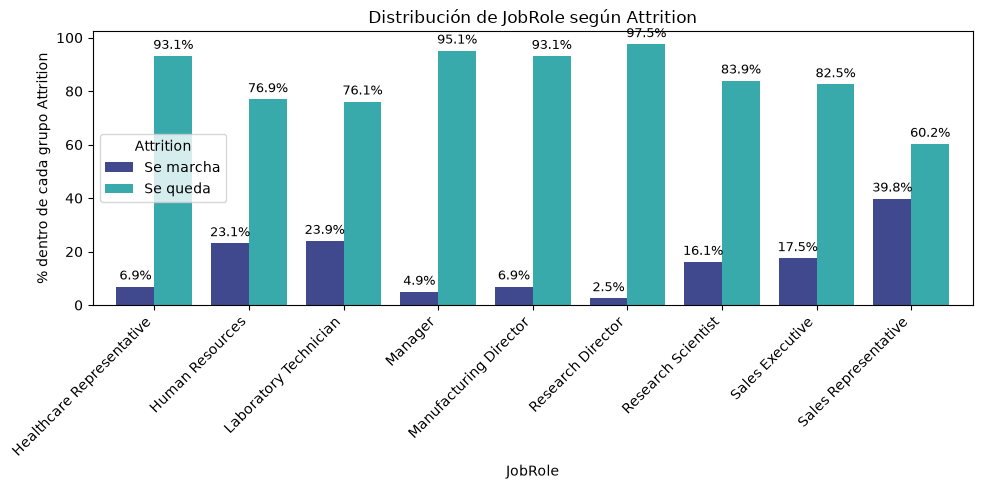

In [69]:
grafico_barras_attrition('JobRole', bins=0, orden=None)

El análisis por `JobRole` confirma que la rotación no se distribuye de forma homogénea entre todos los puestos. El porcentaje de salida es especialmente alto entre los `Sales Representative` (39,8%), seguido de `Laboratory Technician` (23,9%) y `Human Resources` (23,1%). Este patrón complementa lo observado en `MonthlyIncome` y `JobLevel`: los perfiles con menor salario o menor nivel profesional presentan mayor riesgo de salida, pero el tipo de puesto permite concretar mejor dónde se concentra ese riesgo. En cambio, roles de mayor responsabilidad o especialización, como `Manager` o `Research Director`, presentan porcentajes de rotación mucho más bajos.

In [71]:
resumen_jobrole = df_final.groupby("JobRole").agg(
    empleados=("JobRole", "count"),
    salario_medio=("MonthlyIncome", "mean"),
    salario_mediano=("MonthlyIncome", "median"),
    joblevel_medio=("JobLevel", "mean"),
    joblevel_mediano=("JobLevel", "median"),
    rotacion=("Attrition", "mean")
).reset_index()

# Pasamos rotación a porcentaje
resumen_jobrole["rotacion"] = resumen_jobrole["rotacion"] * 100

# Ordenamos de mayor a menor rotación
resumen_jobrole = resumen_jobrole.sort_values("rotacion", ascending=False)

resumen_jobrole["salario_medio"] = resumen_jobrole["salario_medio"].round(2)
resumen_jobrole["salario_mediano"] = resumen_jobrole["salario_mediano"].round(2)
resumen_jobrole["joblevel_medio"] = resumen_jobrole["joblevel_medio"].round(2)
resumen_jobrole["joblevel_mediano"] = resumen_jobrole["joblevel_mediano"].round(2)
resumen_jobrole["rotacion"] = resumen_jobrole["rotacion"].round(2)

resumen_jobrole

,JobRole,empleados,salario_medio,salario_mediano,joblevel_medio,joblevel_mediano,rotacion
8,Sales Representative,83,2673.16,2579.0,1.08,1.0,39.76
2,Laboratory Technician,259,3233.68,2886.0,1.24,1.0,23.94
1,Human Resources,52,4136.56,3093.0,1.48,1.0,23.08
7,Sales Executive,326,6912.37,6222.0,2.33,2.0,17.48
6,Research Scientist,292,3255.41,2893.0,1.20,1.0,16.10
4,Manufacturing Director,145,7294.48,6447.0,2.45,2.0,6.90
0,Healthcare Representative,131,7437.98,6781.0,2.47,2.0,6.87
3,Manager,102,17034.43,17435.0,4.30,4.0,4.90
5,Research Director,80,16033.55,16510.0,3.98,4.0,2.50


Al cruzar `JobRole` con `MonthlyIncome`, `JobLevel` y rotación, se observa que los puestos con mayor porcentaje de salida coinciden, en general, con perfiles de menor nivel profesional y menor salario. El caso más evidente es `Sales Representative`, que presenta la mayor rotación, con un 39,76%, y al mismo tiempo el salario mediano más bajo de todos los roles analizados, 2.579, junto con un `JobLevel` mediano de 1. También destacan `Laboratory Technician` y `Human Resources`, ambos con niveles medianos de 1 y tasas de rotación superiores al 23%.

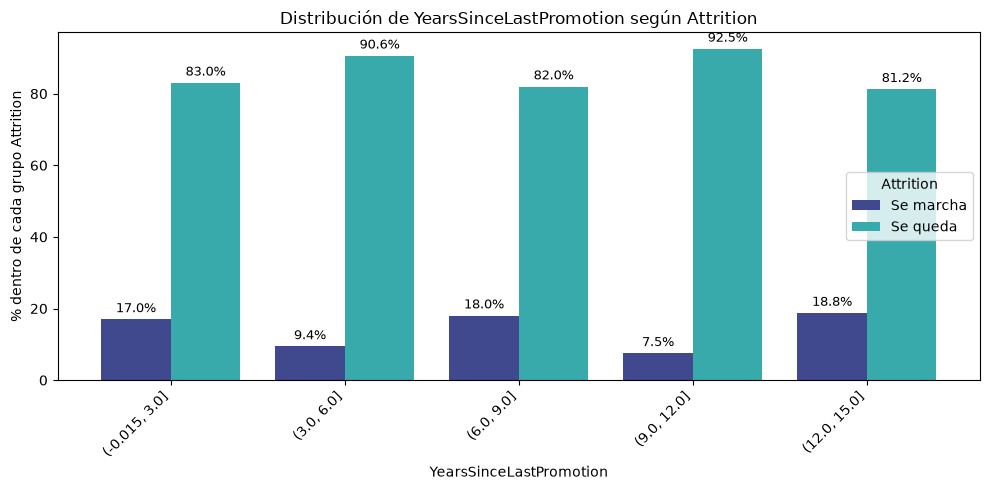

In [56]:
grafico_barras_attrition('YearsSinceLastPromotion', bins=5, orden=None)

En el caso de `YearsSinceLastPromotion`, la relación con la rotación no es lineal ni especialmente clara. Aunque algunos tramos con más años desde el último ascenso presentan porcentajes de salida elevados, también hay intervalos intermedios con porcentajes más bajos. Por tanto, esta variable no permite afirmar por sí sola que la falta de promoción sea un factor determinante de la rotación, aunque sí podría estar influyendo en determinados perfiles.

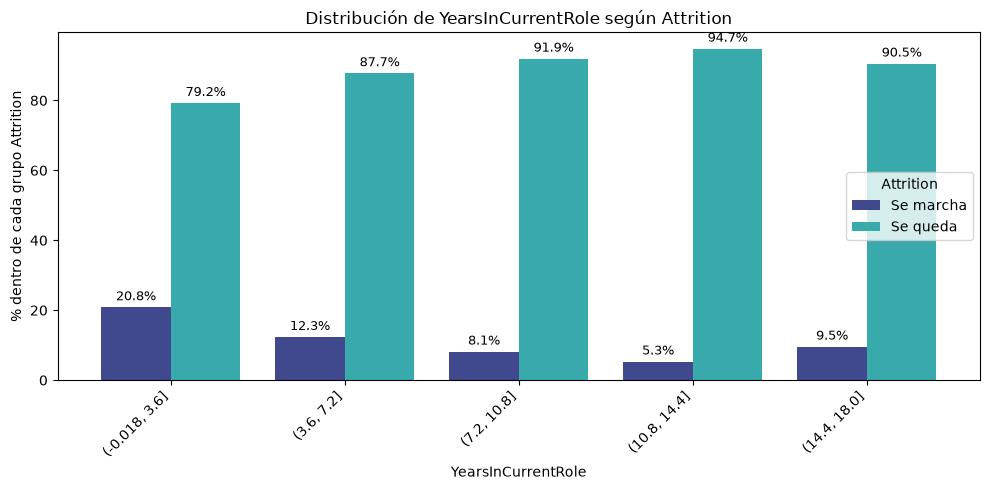

In [57]:
grafico_barras_attrition('YearsInCurrentRole', bins=5, orden=None)

Al analizar el porcentaje de salida dentro de cada tramo de `YearsInCurrentRole`, se observa que la rotación es más elevada entre quienes llevan menos tiempo en su puesto actual. En el primer intervalo, el 20,8% de los empleados abandona la empresa, mientras que en los tramos posteriores el porcentaje desciende de forma general. Esto sugiere que la salida parece estar más vinculada a fases iniciales de adaptación al rol que a una permanencia prolongada en el mismo puesto.

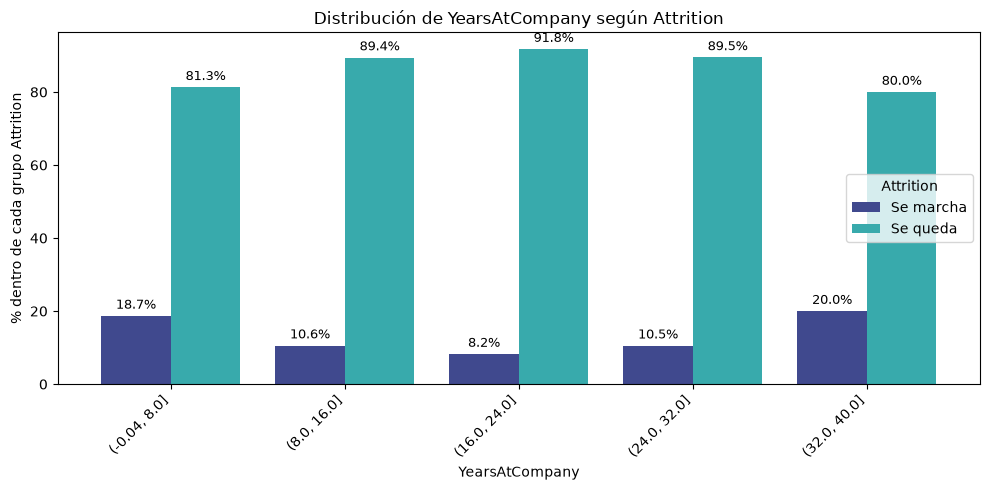

In [66]:
grafico_barras_attrition('YearsAtCompany', bins=5, orden=None)

En `YearsAtCompany`, el porcentaje de salida es más alto entre los empleados con menor antigüedad, especialmente en el tramo de 0 a 8 años. Los tramos intermedios presentan porcentajes de rotación más bajos, lo que sugiere una mayor estabilidad entre empleados con recorrido consolidado en la empresa. Aunque el tramo de mayor antigüedad también muestra un porcentaje elevado de salida, este resultado debe interpretarse con cautela, ya que probablemente corresponde a un número reducido de empleados, que al estar en el intervalo de 32 a 40 años en la empresa, es posible que algunas de salidas se deban a la jubilación.

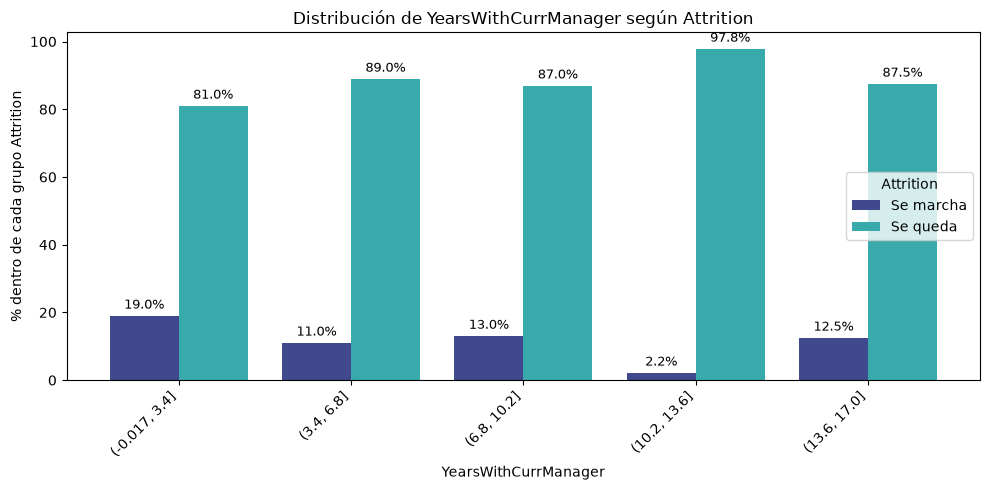

In [59]:
grafico_barras_attrition('YearsWithCurrManager', bins=5, orden=None)

Este gráfico viene a confirmar la lectura anterior, quienes llevan menos años son quienes presentan porcentajes más altos de abandono. En cualquier caso, para analizar la influencia del manager, habría que identificar a los manager y hacer un análisis individualizado de cada equipo, para observar si alguno presenta una rotación más alta que las demás.

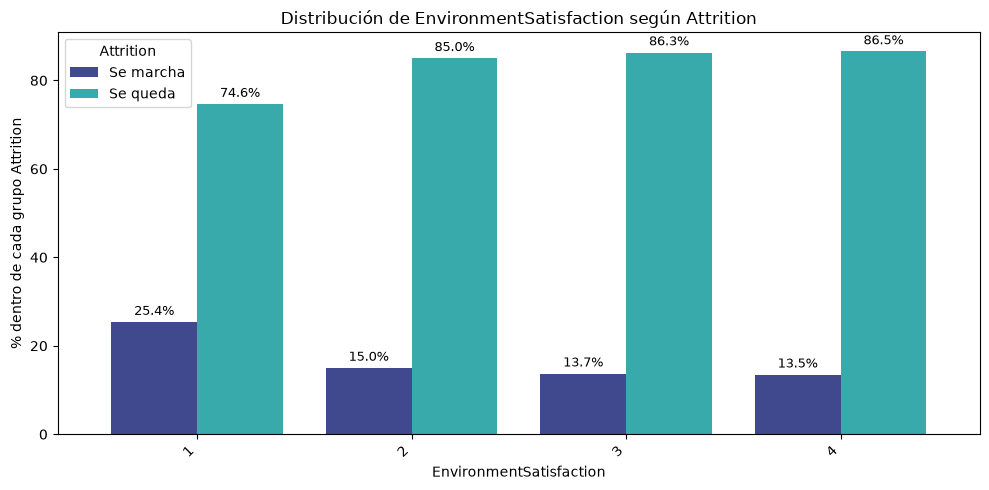

In [60]:
grafico_barras_attrition('EnvironmentSatisfaction', bins=0, orden=None)

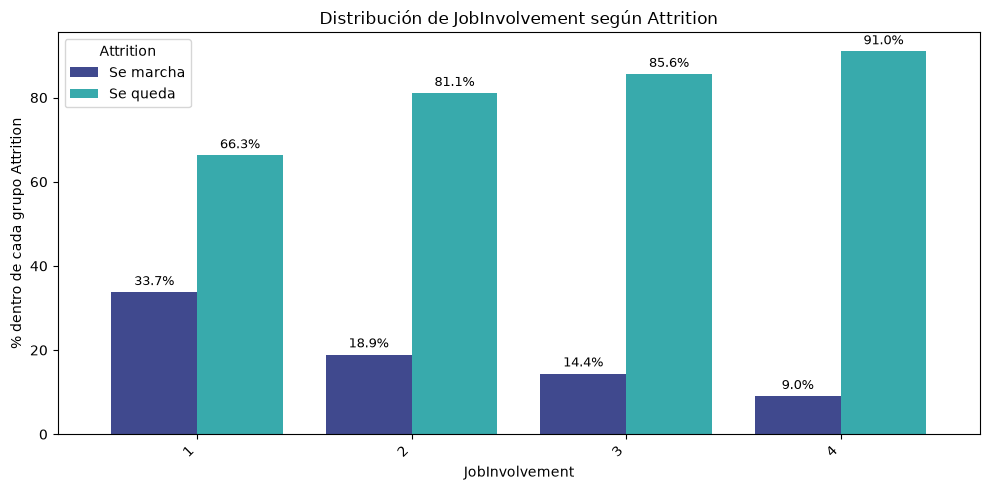

In [61]:
grafico_barras_attrition('JobInvolvement', bins=0, orden=None)

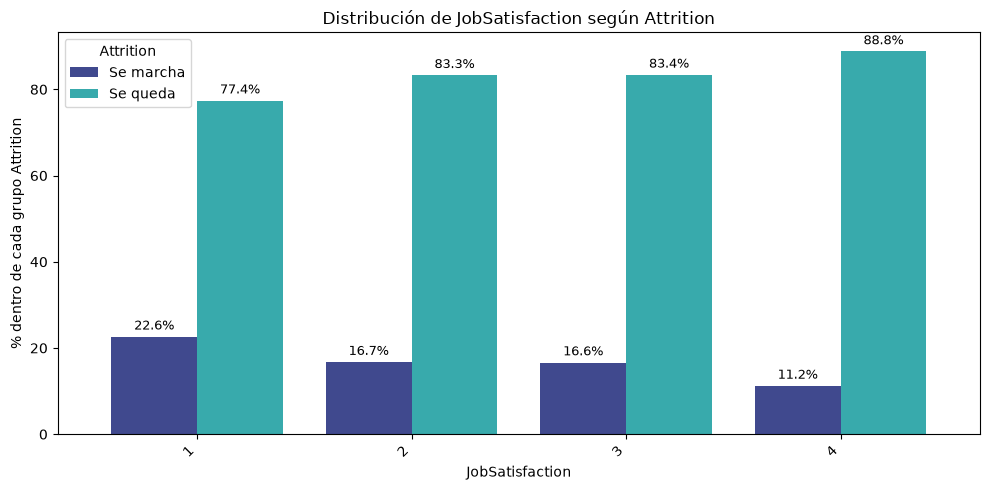

In [62]:
grafico_barras_attrition('JobSatisfaction', bins=0, orden=None)

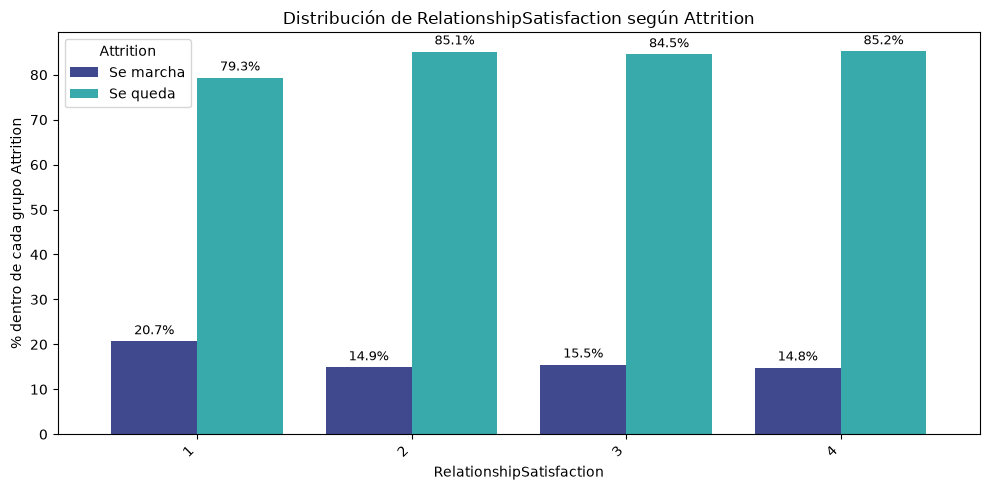

In [63]:
grafico_barras_attrition('RelationshipSatisfaction', bins=0, orden=None)

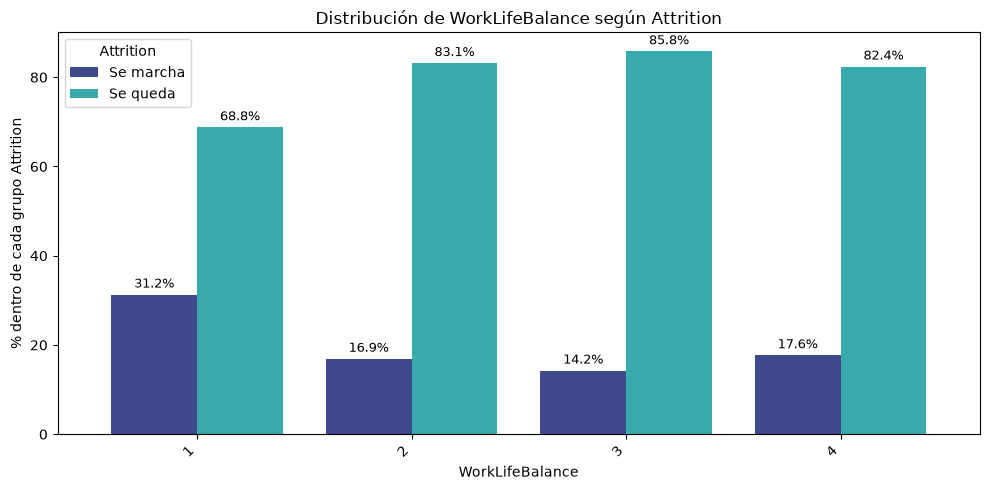

In [64]:
grafico_barras_attrition('WorkLifeBalance', bins=0, orden=None)

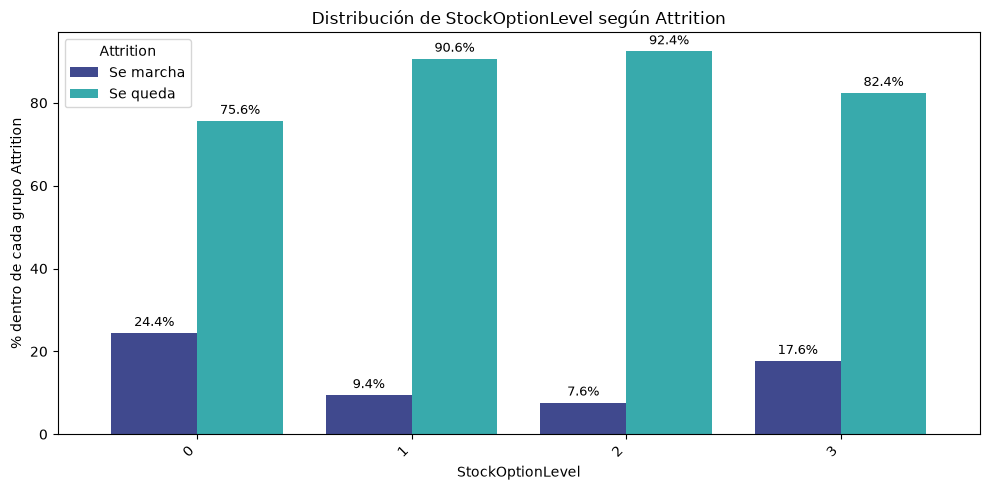

In [72]:
grafico_barras_attrition('StockOptionLevel', bins=0, orden=None)

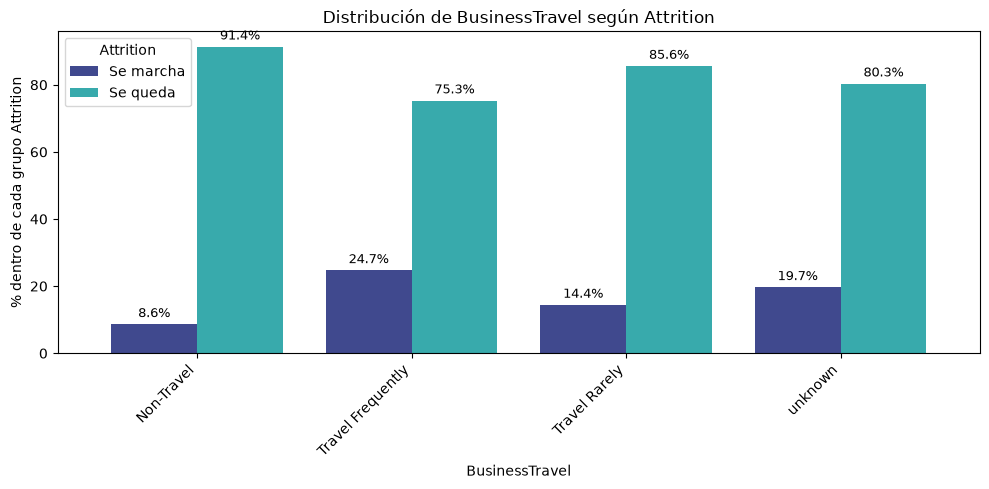

In [73]:
grafico_barras_attrition('BusinessTravel', bins=0, orden=None)